# Logistic Approximation Version 1.1
I want to now try using a logistic function instead for approximation of prices.

In [56]:
# Let's start off by loading in the packages
import pandas as pd
# import datetime
import os
# import timeit
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import beta

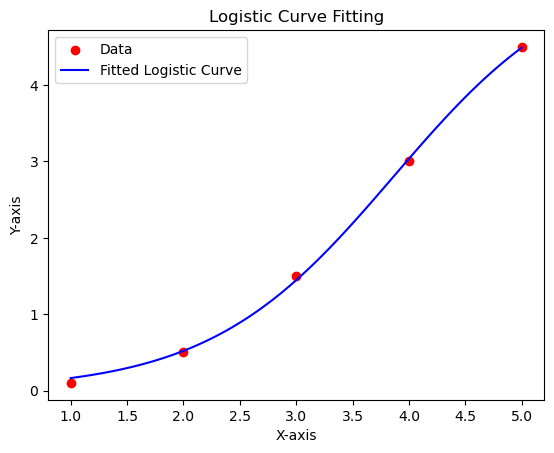

In [57]:
##### CHAT GPT EXAMPLE ####

# Define the logistic function
def logistic(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

# Example data
x_data = np.array([1, 2, 3, 4, 5])
y_data = np.array([0.1, 0.5, 1.5, 3.0, 4.5])

# Fit the curve
popt, pcov = curve_fit(logistic, x_data, y_data, p0=[max(y_data), 1, np.median(x_data)])

# Extract the optimal parameters
L, k, x0 = popt

# Generate data for the fitted curve
x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit = logistic(x_fit, *popt)

# Plot the results
plt.scatter(x_data, y_data, label='Data', color='red')
plt.plot(x_fit, y_fit, label='Fitted Logistic Curve', color='blue')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.title('Logistic Curve Fitting')
plt.show()


In [58]:
#### Now let's try using our merit data:

file_name = os.fsdecode("marco_data.csv")
workbook = pd.read_csv(file_name)
workbook = workbook.filter(items=["date", "he", "size","flexible","price","ail","mkt_price"]) # Gets the columns that we need


workbook = workbook.query('date=="2024-04-10"') # Remove this to take out the filter for the day.

# Getting the columns we need.
# merit_data = workbook.filter(items=["date", "he", "size","flexible","price","mkt_price","ail","datetime"]) # Gets the columns that we need
merit_data = workbook
# I added "datetime" above so that it will be easier to filter out the merit data when looping through.

# For this let's just use one day of data:
merit_data = merit_data[merit_data['he']==19].reset_index(drop = True)
# And now let's add the merit
merit_data['merit'] = merit_data['size'].cumsum()


In [59]:
# Let's get rid first of the zero-price bids
merit_data = merit_data[merit_data['price']>0]

# Let's try normalizing our data to see what happens
merit_data['merit_norm'] = merit_data['merit']/merit_data['merit'].max()
merit_data['price_norm'] = merit_data['price']/1000
merit_data

,date,he,size,flexible,price,ail,mkt_price,merit,merit_norm,price_norm
174,2024-04-10,19,11.0,Y,9.98,9296.975,31.51,8263.975,0.713952,0.00998
175,2024-04-10,19,45.0,Y,13.77,9296.975,31.51,8308.975,0.717840,0.01377
176,2024-04-10,19,40.0,Y,14.77,9296.975,31.51,8348.975,0.721295,0.01477
177,2024-04-10,19,130.0,Y,15.00,9296.975,31.51,8478.975,0.732526,0.01500
178,2024-04-10,19,7.0,Y,15.60,9296.975,31.51,8485.975,0.733131,0.01560
...,...,...,...,...,...,...,...,...,...,...
276,2024-04-10,19,16.0,Y,999.99,9296.975,31.51,11233.975,0.970540,0.99999
277,2024-04-10,19,42.0,N,999.99,9296.975,31.51,11275.975,0.974168,0.99999
278,2024-04-10,19,80.0,Y,999.99,9296.975,31.51,11355.975,0.981080,0.99999
279,2024-04-10,19,109.0,Y,999.99,9296.975,31.51,11464.975,0.990497,0.99999


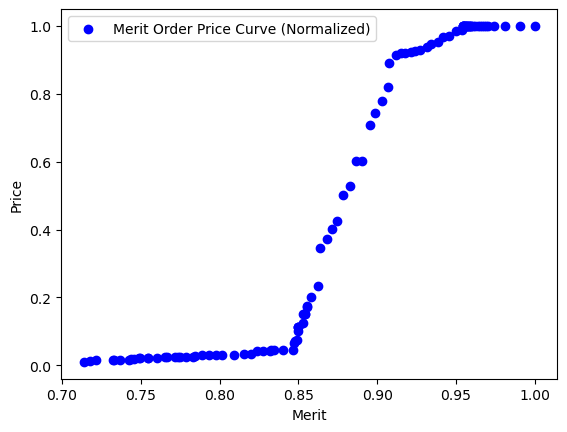

In [60]:
plt.scatter(merit_data['merit_norm'], merit_data['price_norm'], label='Merit Order Price Curve (Normalized)', color='blue')
plt.xlabel('Merit')
plt.ylabel('Price')
plt.legend()
plt.title('')
plt.show()

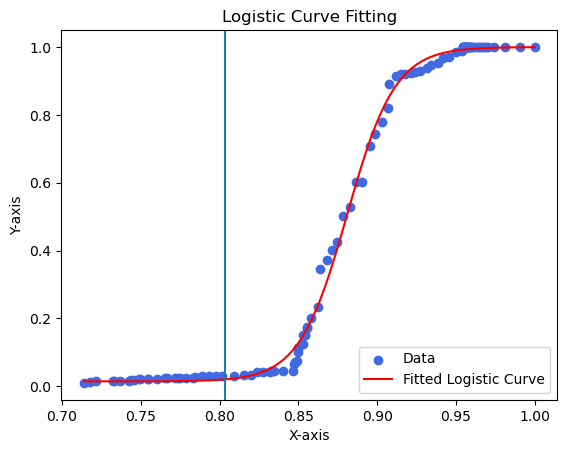

In [61]:
# Now let's use what Chat GPT gave us

# Define the logistic function
def logistic(x, L, k, x0, shift):
    return L / (1 + np.exp(-k * (x - x0))) + shift

# Example data
x_data = merit_data['merit_norm']
y_data = merit_data['price_norm']

# Fit the curve
# NOTE: the array p0 is the initial guess for all the parameters.
popt, pcov = curve_fit(logistic, x_data, y_data, p0=[max(y_data), 1, np.median(x_data),0])

# Extract the optimal parameters
L, k, x0, shift = popt

# Generate data for the fitted curve
x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit = logistic(x_fit, *popt)

# Plot the results
plt.scatter(x_data, y_data, label='Data', color='royalblue')
plt.plot(x_fit, y_fit, label='Fitted Logistic Curve', color='red')
plt.axvline(merit_data['ail'].min()/merit_data['merit'].max())
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.title('Logistic Curve Fitting')
plt.show()

In [62]:
[L,k,x0,shift]

[0.9850385034829223,
 65.85398538594505,
 0.8810027344266886,
 0.014625025996236642]

In [63]:
merit_data['ail']

174    9296.975
175    9296.975
176    9296.975
177    9296.975
178    9296.975
         ...   
276    9296.975
277    9296.975
278    9296.975
279    9296.975
280    9296.975
Name: ail, Length: 107, dtype: float64